# Dataset Demo - Satellite Lightning: MTG LI

This notebook demonstrates the use of [EUMETSAT's Meteosat Third Generation Lighning Imager (MTG LI)](https://user.eumetsat.int/resources/user-guides/mtg-li-level-2-data-guide) datset with PyEarthTools.

### EW4Energy Dataset info
* Duration: 6 months -  April to September 2025
* Temporal Resoltuion file per 15 minutes (20MB per file)
* Spatial Extent
  * Latitude 0N to 20N
  * Longitude 27W to 20E


In [2]:
import os
import pathlib

In [21]:
import matplotlib
import cartopy

In [56]:
import iris

In [3]:
import xarray

In [4]:
path1 = pathlib.Path('/gws/nopw/j04/ew4energy/MTG_LI/20250422/flash_accumulation_20250422094500_15mins.nc')

In [59]:
mtg_li_cube = iris.load(path1)

In [60]:
mtg_li_cube

[<iris 'Cube' of Flash Accumulation / (unknown) (-- : 1058; -- : 2327)>,
<iris 'Cube' of latitude / (degrees) (-- : 1058; -- : 2327)>,
<iris 'Cube' of longitude / (degrees) (-- : 1058; -- : 2327)>]

In [63]:
mtg_li_ds['flash_accumulation'].values.max()

np.float32(22.883001)

In [41]:
mtg_li_ds = xarray.open_dataset(path1)

In [45]:
mtg_li_ds['longitude'][0,:20].data

array([-27.115114, -27.091827, -27.06855 , -27.045279, -27.022017,
       -26.99876 , -26.975513, -26.952274, -26.92904 , -26.905817,
       -26.8826  , -26.859392, -26.836191, -26.812998, -26.78981 ,
       -26.766632, -26.743462, -26.720299, -26.697144, -26.673994],
      dtype=float32)

In [46]:
mtg_li_ds

<xarray.Dataset> Size: 30MB
Dimensions:             (y: 1058, x: 2327)
Dimensions without coordinates: y, x
Data variables:
    latitude            (y, x) float32 10MB ...
    longitude           (y, x) float32 10MB ...
    flash_accumulation  (y, x) float32 10MB ...
Attributes:
    title:                Accumulated flash_accumulation from MTG Lightning I...
    institution:          NCAS Leeds
    source:               MTG Lightning Imager
    history:              Created 2025-10-03T15:12:02.989146Z
    time_coverage_start:  2025-04-22T09:30:29Z
    time_coverage_end:    2025-04-22T09:44:59Z

In [51]:
mtg_li_ds = mtg_li_ds.set_coords(['latitude','longitude'])
mtg_li_ds

<xarray.Dataset> Size: 30MB
Dimensions:             (y: 1058, x: 2327)
Coordinates:
    latitude            (y, x) float32 10MB ...
    longitude           (y, x) float32 10MB ...
Dimensions without coordinates: y, x
Data variables:
    flash_accumulation  (y, x) float32 10MB ...
Attributes:
    title:                Accumulated flash_accumulation from MTG Lightning I...
    institution:          NCAS Leeds
    source:               MTG Lightning Imager
    history:              Created 2025-10-03T15:12:02.989146Z
    time_coverage_start:  2025-04-22T09:30:29Z
    time_coverage_end:    2025-04-22T09:44:59Z

In [50]:
mtg_li_ds

<xarray.Dataset> Size: 30MB
Dimensions:             (y: 1058, x: 2327)
Dimensions without coordinates: y, x
Data variables:
    latitude            (y, x) float32 10MB ...
    longitude           (y, x) float32 10MB ...
    flash_accumulation  (y, x) float32 10MB ...
Attributes:
    title:                Accumulated flash_accumulation from MTG Lightning I...
    institution:          NCAS Leeds
    source:               MTG Lightning Imager
    history:              Created 2025-10-03T15:12:02.989146Z
    time_coverage_start:  2025-04-22T09:30:29Z
    time_coverage_end:    2025-04-22T09:44:59Z

In [35]:
mtg_li_ds['flash_accumulation'].set_coords(x='longitude',y='latitude')

<xarray.DataArray 'flash_accumulation' (y: 1058, x: 2327)> Size: 10MB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1058, 2327), dtype=float32)
Coordinates:
    y        <U8 32B 'latitude'
    x        <U9 36B 'longitude'
Attributes:
    units:      flashes/pixel
    long_name:  Flash Accumulation

In [12]:
float(mtg_li_ds['latitude'].min()), float(mtg_li_ds['latitude'].max()), float(mtg_li_ds['longitude'].min()), float(mtg_li_ds['longitude'].max())

(0.027131086215376854,
 20.190547943115234,
 -27.115114212036133,
 19.97930908203125)

In [15]:
[var1 for var1 in mtg_li_ds.variables]

['latitude', 'longitude', 'flash_accumulation']

In [55]:
mtg_li_ds['latitude']


<xarray.DataArray 'latitude' (y: 1058, x: 2327)> Size: 10MB
[2461966 values with dtype=float32]
Coordinates:
    latitude   (y, x) float32 10MB ...
    longitude  (y, x) float32 10MB ...
Dimensions without coordinates: y, x
Attributes:
    units:          degrees_north
    standard_name:  latitude

In [64]:
48*30*65/1024


91.40625

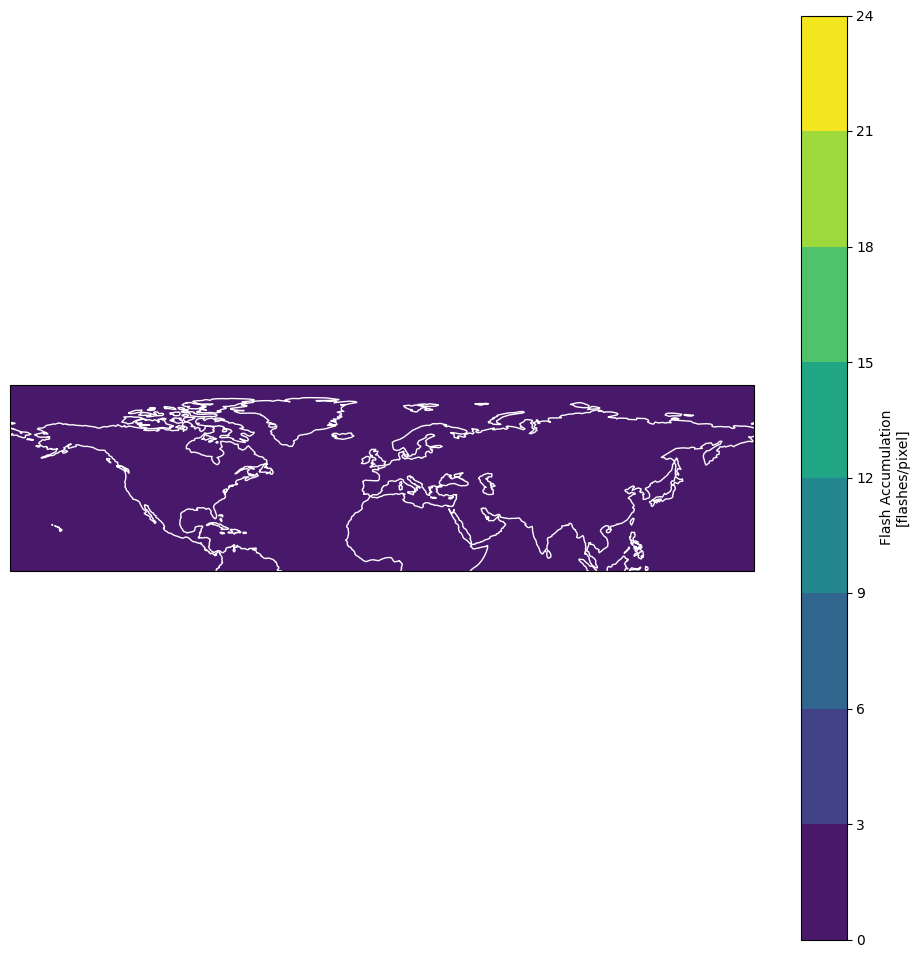

In [53]:
fig1 = matplotlib.pyplot.figure(figsize=(12,12))
ax1=fig1.add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())
mtg_li_ds['flash_accumulation'].plot.contourf(ax=ax1)
ax1.coastlines(color='w')


In [13]:
iris.load('/gws/nopw/j04/ew4energy/TOOCAN-AFRICA-20240801-20240831.nc')

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/iris/fileformats/_nc_load_rules/helpers.py:1091: _WarnComboIgnoringCfLoad: Ignoring invalid units 'semiminor/semimajor' on netCDF variable 'LC_ecc_235K'.
  warnings.warn(
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/iris/fileformats/_nc_load_rules/helpers.py:1091: _WarnComboIgnoringCfLoad: Ignoring invalid units 'none' on netCDF variable 'DCS'.
  warnings.warn(
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/iris/fileformats/_nc_load_rules/helpers.py:1091: _WarnComboIgnoringCfLoad: Ignoring invalid units 'number of pixels' on netCDF variable 'LC_surfPix_210K'.
  warnings.warn(
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/iris/fileform

[<iris 'Cube' of Eccentricity of the equivalent ellipse at a 235K threshold / (unknown) (Label of the Deep Convective Systems: 30647; time: 3041)>,
<iris 'Cube' of Cold cloud surface in km2 of the convective cluster for a 235K threshold / (km2) (Label of the Deep Convective Systems: 30647; time: 3041)>,
<iris 'Cube' of Average velocity of the DCS from its initiation to its dissipation / (m/s) (Label of the Deep Convective Systems: 30647)>,
<iris 'Cube' of instantaneous velocity / (m/s) (Label of the Deep Convective Systems: 30647; time: 3041)>,
<iris 'Cube' of Average brightness temperature at 235K / (K) (Label of the Deep Convective Systems: 30647; time: 3041)>,
<iris 'Cube' of Longitude of the DCS center of mass at its initiation / (degrees) (Label of the Deep Convective Systems: 30647)>,
<iris 'Cube' of Cold cloud surface in number of pixels of the convective cluster for a 210K threshold / (unknown) (Label of the Deep Convective Systems: 30647; time: 3041)>,
<iris 'Cube' of Minimum brightness temperature of the DCS along its life cycle / (K) (Label of the Deep Convective Systems: 30647)>,
<iris 'Cube' of Classification of the DCS according to Roca etal (2017) / (no_unit) (Label of the Deep Convective Systems: 30647)>,
<iris 'Cube' of Semi-major axis of the equivalent ellipse at a 220K threshold / (km) (Label of the Deep Convective Systems: 30647; time: 3041)>,
<iris 'Cube' of orientation of the equivalent ellipse at a 235K threshold / (degrees) (Label of the Deep Convective Systems: 30647; time: 3041)>,
<iris 'Cube' of Maximum cold cloud surface at 210K reached  by the DCS along its life cycle / (km2) (Label of the Deep Convective Systems: 30647)>,
<iris 'Cube' of Average brightness temperature at 208K / (K) (Label of the Deep Convective Systems: 30647; time: 3041)>,
<iris 'Cube' of Maximum latitude of the DCS along its life cycle / (degrees) (Label of the Deep Convective Systems: 30647)>,
<iris 'Cube' of Minimum longitude of the DCS along its life cycle / (degrees) (Label of the Deep Convective Systems: 30647)>,
<iris 'Cube' of Tb 90th percentile / (K) (Label of the Deep Convective Systems: 30647; time: 3041)>,
<iris 'Cube' of Cold cloud surface in number of pixels of the convective cluster for a 235K threshold / (unknown) (Label of the Deep Convective Systems: 30647; time: 3041)>,
<iris 'Cube' of Line of the DCS center of mass / (unknown) (Label of the Deep Convective Systems: 30647; time: 3041)>,
<iris 'Cube' of Cold cloud surface in km2 of the convective cluster for a 210K threshold / (km2) (Label of the Deep Convective Systems: 30647; time: 3041)>,
<iris 'Cube' of DCS progagated distance / (km) (Label of the Deep Convective Systems: 30647)>,
<iris 'Cube' of Longitude of the DCS center of mass at its dissipation / (degrees) (Label of the Deep Convective Systems: 30647)>,
<iris 'Cube' of Maximum cold cloud surface at 200K reached  by the DCS along its life cycle / (km2) (Label of the Deep Convective Systems: 30647)>,
<iris 'Cube' of Label of the DCS in the TOOCAN segmented images / (unknown) (Label of the Deep Convective Systems: 30647)>,
<iris 'Cube' of orientation of the equivalent ellipse at a 220K threshold / (degrees) (Label of the Deep Convective Systems: 30647; time: 3041)>,
<iris 'Cube' of Local time of the DCS initiation initiation / (unknown) (Label of the Deep Convective Systems: 30647)>,
<iris 'Cube' of Latitude of the DCS center of mass at its initiation / (degrees) (Label of the Deep Convective Systems: 30647)>,
<iris 'Cube' of Maximum cold cloud surface at 235K reached by the DCS along its life cycle  / (km2) (Label of the Deep Convective Systems: 30647)>,
<iris 'Cube' of Latitude of the DCS center of mass at its dissipation / (degrees) (Label of the Deep Convective Systems: 30647)>,
<iris 'Cube' of Column of the DCS center of mass / (unknown) (Label of the Deep Convective Systems: 30647; time: 3041)>,
<iris 'Cube' of Universal Time of the DCS initiation  / (unknown) (Label of the Deep Convective Systems: 